# 10 — Dataset Visualization

**Author:** Héctor Fernández Pinacho  
**Lab:** IDEAL Lab  
**Purpose:** Visual overview of the full propeller design pipeline — one section per upstream notebook.


## 1. Imports and style

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    'figure.facecolor': '#1E1E2E', 'axes.facecolor': '#2A2A3E',
    'axes.edgecolor': '#44475A', 'axes.labelcolor': '#CDD6F4',
    'axes.titlecolor': '#CDD6F4', 'axes.titlesize': 12, 'axes.labelsize': 10,
    'axes.grid': True, 'grid.color': '#44475A', 'grid.linewidth': 0.5,
    'xtick.color': '#BAC2DE', 'ytick.color': '#BAC2DE', 'text.color': '#CDD6F4',
    'legend.facecolor': '#313244', 'legend.edgecolor': '#44475A', 'legend.fontsize': 9,
    'figure.titlesize': 13, 'figure.titleweight': 'bold', 'lines.linewidth': 1.5,
})

C = {
    'blue':    '#89B4FA', 'green':  '#A6E3A1', 'red':    '#F38BA8',
    'yellow':  '#F9E2AF', 'mauve':  '#CBA6F7', 'teal':   '#94E2D5',
    'peach':   '#FAB387', 'overlay':'#585B70', 'text':   '#CDD6F4',
    'sky':     '#89DCEB', 'pink':   '#F5C2E7',
}

def ok(df):
    return df is not None and len(df) > 0

def styled_box(ax, data, labels, colors):
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col); patch.set_alpha(0.75)
    for el in ['whiskers', 'caps']:
        for item in bp[el]: item.set_color(C['overlay'])
    return bp

## 2. Data loading

In [2]:
BASE_DIR = Path('.')
CSV_DIR  = BASE_DIR / 'csv'

def load(filename, **kwargs):
    path = CSV_DIR / filename
    if not path.exists():
        print(f'  [skip] {filename} not found.')
        return None
    df = pd.read_csv(path, **kwargs)
    print(f'  [ok]   {filename}  —  {len(df):,} rows')
    return df

print('Loading pipeline CSVs...')
geo_df    = load('prop_geometrical_params.csv')
mass_df   = load('prop_mass_estimation.csv')
naca_df   = load('naca_codes.csv', dtype={'naca_hub': str, 'naca_inner': str, 'naca_mid': str, 'naca_outer': str})
xfoil_df  = load('xfoil_profile_simulation.csv')
qprop_df  = load('qprop_batch_results.csv')
flight_df = load('flight_dynamics.csv')
rep_df    = load('representative_propellers.csv')
stl_df    = load('rhino_stl_generation.csv')
vol_df    = load('prop_stl_volumes.csv')

Loading pipeline CSVs...
  [ok]   prop_geometrical_params.csv  —  5,000 rows
  [ok]   prop_mass_estimation.csv  —  5,000 rows
  [ok]   naca_codes.csv  —  5,000 rows
  [ok]   xfoil_profile_simulation.csv  —  5,000 rows
  [ok]   qprop_batch_results.csv  —  5,000 rows
  [ok]   flight_dynamics.csv  —  5,000 rows
  [ok]   representative_propellers.csv  —  100 rows
  [ok]   rhino_stl_generation.csv  —  5,000 rows
  [ok]   prop_stl_volumes.csv  —  100 rows


## 3. Pipeline availability

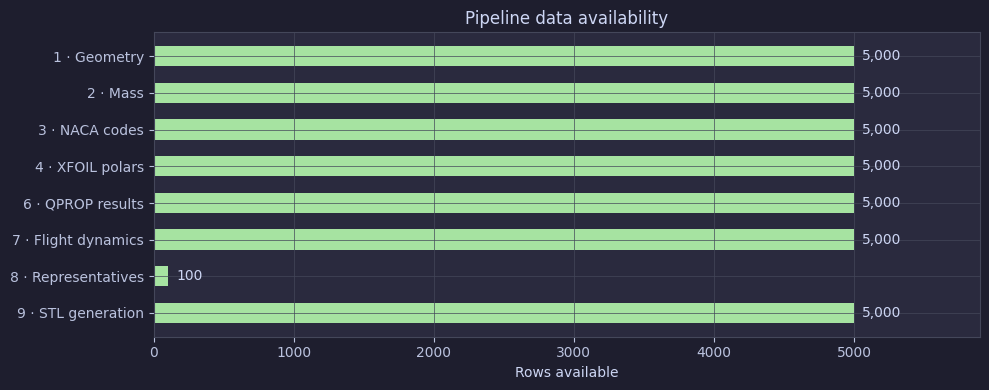

In [3]:
stages = [
    ('1 · Geometry',        geo_df),
    ('2 · Mass',            mass_df),
    ('3 · NACA codes',      naca_df),
    ('4 · XFOIL polars',    xfoil_df),
    ('6 · QPROP results',   qprop_df),
    ('7 · Flight dynamics', flight_df),
    ('8 · Representatives', rep_df),
    ('9 · STL generation',  stl_df),
]
labels = [s[0] for s in stages]
counts = [len(s[1]) if ok(s[1]) else 0 for s in stages]
colors = [C['green'] if c > 0 else C['red'] for c in counts]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels, counts, color=colors, height=0.55)
ax.bar_label(bars, labels=[f'{c:,}' if c > 0 else 'missing' for c in counts],
             padding=6, color=C['text'], fontsize=10)
ax.set_xlabel('Rows available')
ax.set_title('Pipeline data availability')
ax.invert_yaxis()
ax.set_xlim(0, max(counts) * 1.18 if max(counts) > 0 else 10)
fig.tight_layout()
plt.show()

## 4. Notebook 1 — Geometry

Global parameter distributions and radial blade evolution.

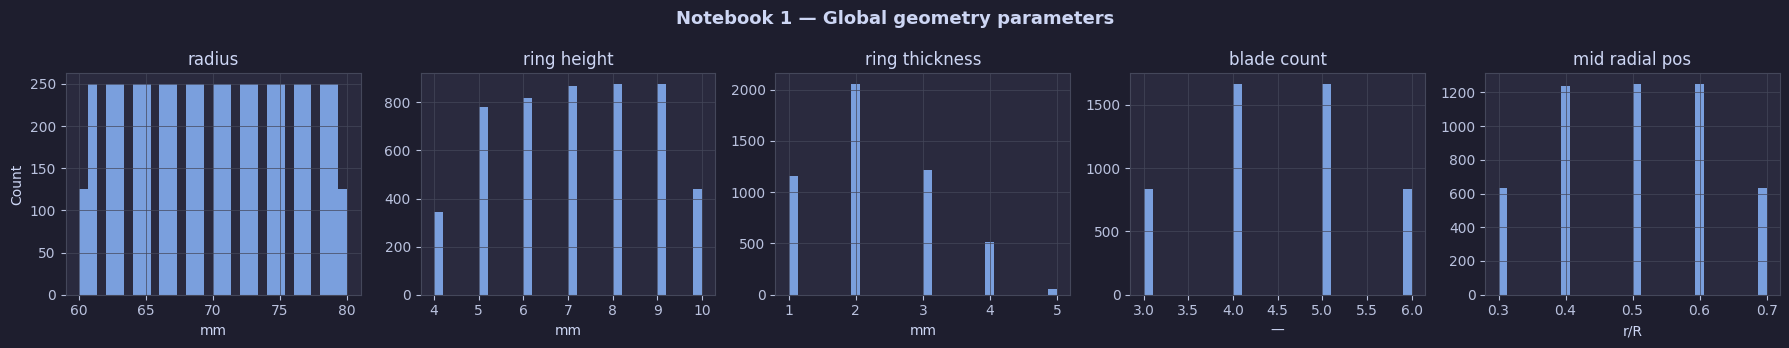

In [4]:
# 4a — Global parameter histograms
if not ok(geo_df):
    print('Geometry CSV not available — skipping.')
else:
    global_cols = ['radius', 'ring height', 'ring thickness', 'blade count', 'mid radial pos']
    units       = ['mm', 'mm', 'mm', '—', 'r/R']
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
    fig.suptitle('Notebook 1 — Global geometry parameters')
    for ax, col, unit in zip(axes, global_cols, units):
        ax.hist(geo_df[col].dropna(), bins=30, color=C['blue'], edgecolor='none', alpha=0.85)
        ax.set_title(col); ax.set_xlabel(unit)
        ax.set_ylabel('Count' if ax is axes[0] else '')
    fig.tight_layout()
    plt.show()

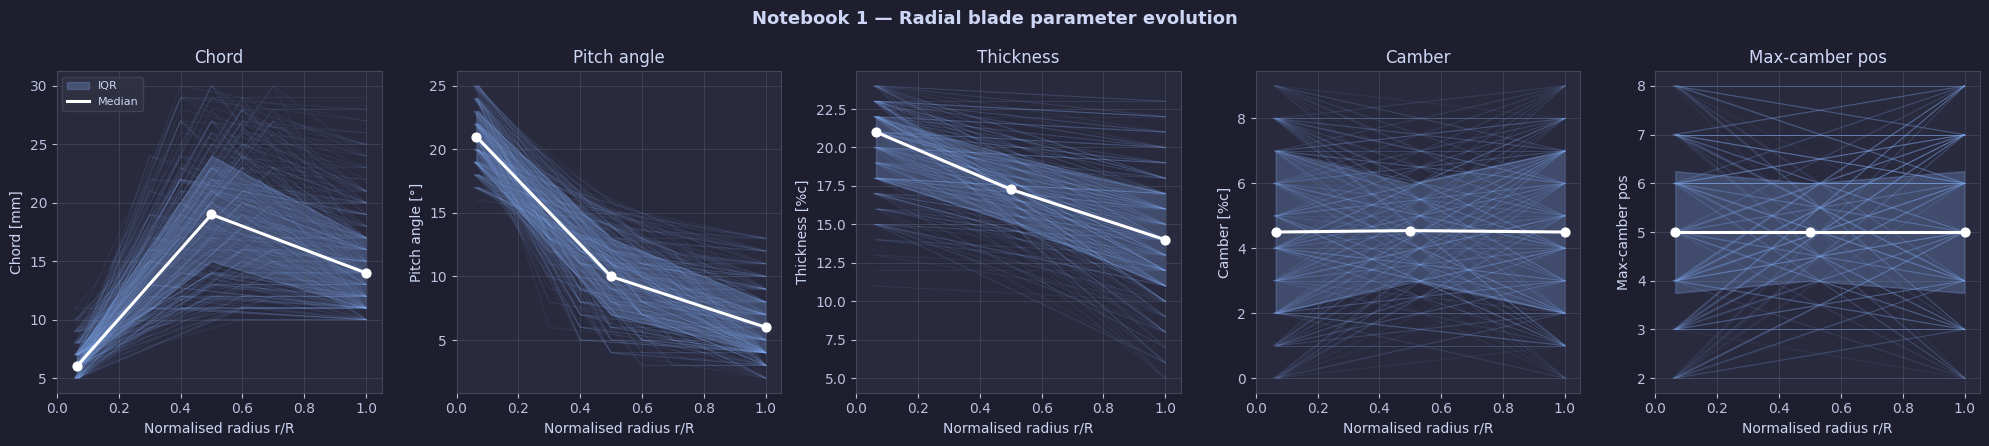

In [5]:
# 4b — Radial evolution of all blade parameters
# Stations: inner (r ≈ 4.5/radius), middle (mid radial pos), outer (r/R = 1.0)
# Each line is one config; median ± IQR band shown on top.

if ok(geo_df):
    INNER_R_MM = 4.5

    radial_params = [
        ('Chord [mm]',        ['inner chord',    'mid chord',    'outer chord']),
        ('Pitch angle [°]',   ['inner angle',    'mid angle',    'outer angle']),
        ('Thickness [%c]',    ['inner thickness', None,          'outer thickness']),
        ('Camber [%c]',       ['inner camber',   None,           'outer camber']),
        ('Max-camber pos',    ['inner max pos',  None,           'outer max pos']),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
    fig.suptitle('Notebook 1 — Radial blade parameter evolution')

    for ax, (ylabel, cols) in zip(axes, radial_params):
        # Build (r_norm, value) per config per station
        station_r_all  = []
        station_v_all  = []

        for _, row in geo_df.iterrows():
            R = float(row['radius'])
            r_inner = INNER_R_MM / R
            r_mid   = float(row['mid radial pos'])
            r_outer = 1.0
            r_pts   = [r_inner, r_mid, r_outer]

            v_pts = []
            for col, r in zip(cols, r_pts):
                if col is None:
                    # interpolate linearly between inner and outer
                    v_in  = float(row[cols[0]])
                    v_out = float(row[cols[2]])
                    r_in  = INNER_R_MM / R
                    v = v_in + (r - r_in) / (1.0 - r_in) * (v_out - v_in)
                else:
                    v = float(row[col])
                v_pts.append(v)

            station_r_all.append(r_pts)
            station_v_all.append(v_pts)

        r_arr = np.array(station_r_all)   # (N, 3)
        v_arr = np.array(station_v_all)   # (N, 3)

        # Sample up to 300 individual trajectories
        rng  = np.random.default_rng(42)
        idx  = rng.choice(len(r_arr), size=min(300, len(r_arr)), replace=False)
        for i in idx:
            ax.plot(r_arr[i], v_arr[i], color=C['blue'], alpha=0.07, linewidth=0.8)

        # Median and IQR band at each station
        r_med = np.median(r_arr, axis=0)  # representative r positions
        med   = np.median(v_arr, axis=0)
        q25   = np.percentile(v_arr, 25, axis=0)
        q75   = np.percentile(v_arr, 75, axis=0)

        ax.fill_between(r_med, q25, q75, color=C['blue'], alpha=0.25, label='IQR')
        ax.plot(r_med, med, color='white', linewidth=2.2, label='Median')
        ax.scatter(r_med, med, color='white', s=40, zorder=5)

        ax.set_xlabel('Normalised radius r/R')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel.split(' [')[0])
        ax.set_xlim(0, 1.05)

    axes[0].legend(fontsize=8)
    fig.tight_layout()
    plt.show()

## 5. Notebook 2 — Mass estimation

C:\Users\hecto\AppData\Local\Temp\ipykernel_33524\2612799987.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.5,


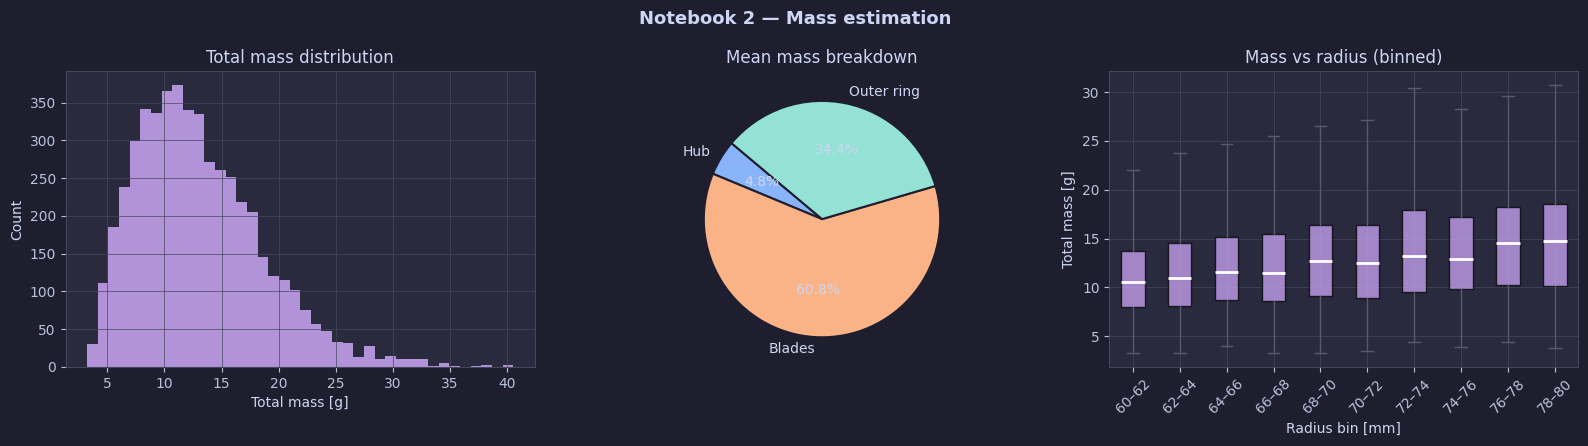

In [6]:
if not ok(mass_df):
    print('Mass CSV not available — skipping.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle('Notebook 2 — Mass estimation')

    # Total mass histogram
    axes[0].hist(mass_df['m_total_kg'] * 1000, bins=40,
                 color=C['mauve'], edgecolor='none', alpha=0.85)
    axes[0].set_xlabel('Total mass [g]'); axes[0].set_ylabel('Count')
    axes[0].set_title('Total mass distribution')

    # Component breakdown pie
    comp_cols   = ['m_hub_kg', 'm_blades_kg', 'm_outer_ring_kg']
    comp_labels = ['Hub', 'Blades', 'Outer ring']
    comp_colors = [C['blue'], C['peach'], C['teal']]
    means = mass_df[comp_cols].mean()
    axes[1].pie(means, labels=comp_labels, colors=comp_colors,
                autopct='%1.1f%%', startangle=140,
                textprops={'color': C['text'], 'fontsize': 10},
                wedgeprops={'edgecolor': '#1E1E2E', 'linewidth': 1.5})
    axes[1].set_title('Mean mass breakdown')

    # Total mass vs radius — candlestick boxplot binned by radius
    if ok(geo_df):
        merged = geo_df[['config_id', 'radius']].merge(
            mass_df[['config_id', 'm_total_kg']], on='config_id')
        r_min  = int(np.floor(merged['radius'].min() / 2) * 2)
        r_max  = int(np.ceil(merged['radius'].max()  / 2) * 2)
        bins   = np.arange(r_min, r_max + 2, 2)
        merged['r_bin'] = pd.cut(merged['radius'], bins=bins)
        groups = [g['m_total_kg'].dropna().values * 1000
                  for _, g in merged.groupby('r_bin', observed=True)]
        bin_labels = [f"{int(b.left)}–{int(b.right)}" for b in
                      merged.groupby('r_bin', observed=True).groups.keys()]

        styled_box(axes[2], groups, bin_labels, [C['mauve']] * len(groups))
        axes[2].set_xlabel('Radius bin [mm]'); axes[2].set_ylabel('Total mass [g]')
        axes[2].set_title('Mass vs radius (binned)')
        axes[2].tick_params(axis='x', rotation=45)

    fig.tight_layout()
    plt.show()

## 6. Notebook 3 — NACA airfoil profiles

For each sampled configuration, plot the four airfoil profiles (hub, inner, mid, outer) including their pitch angle.

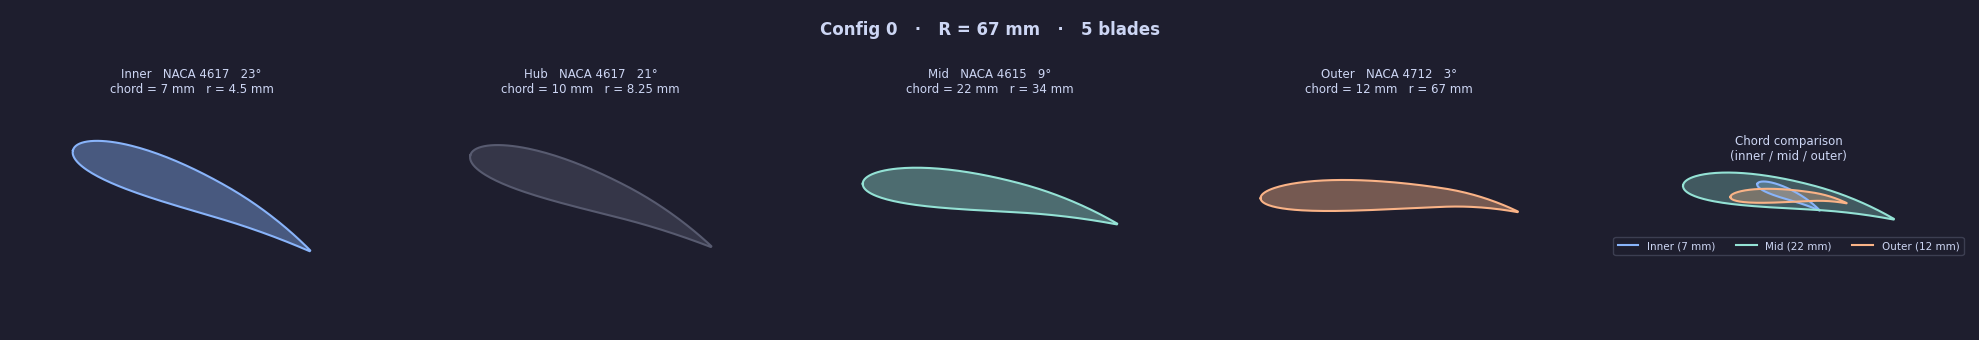

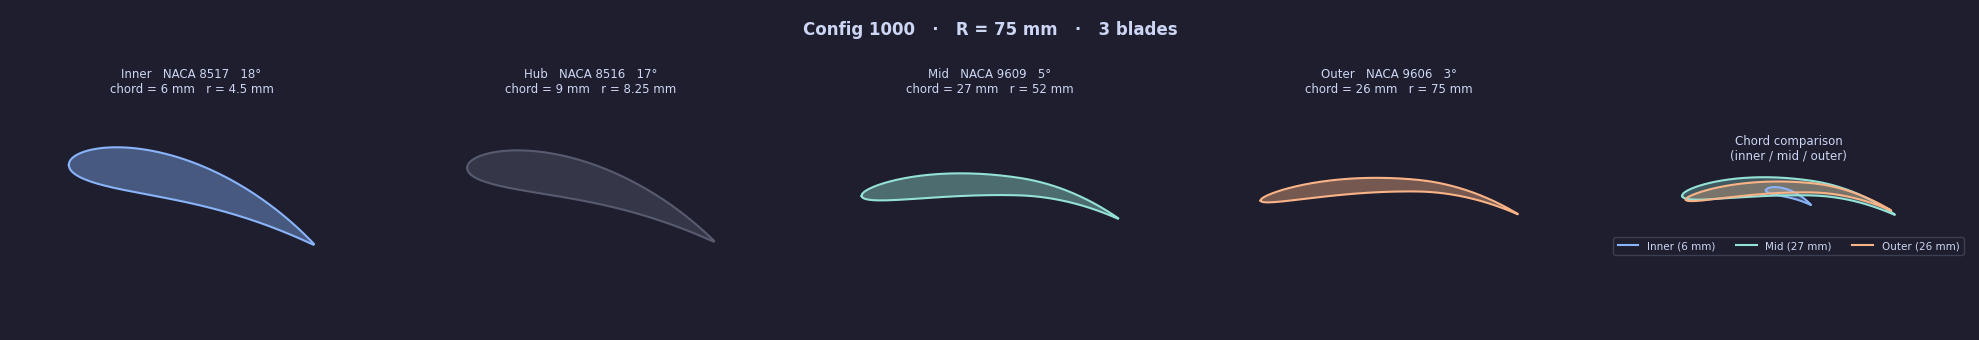

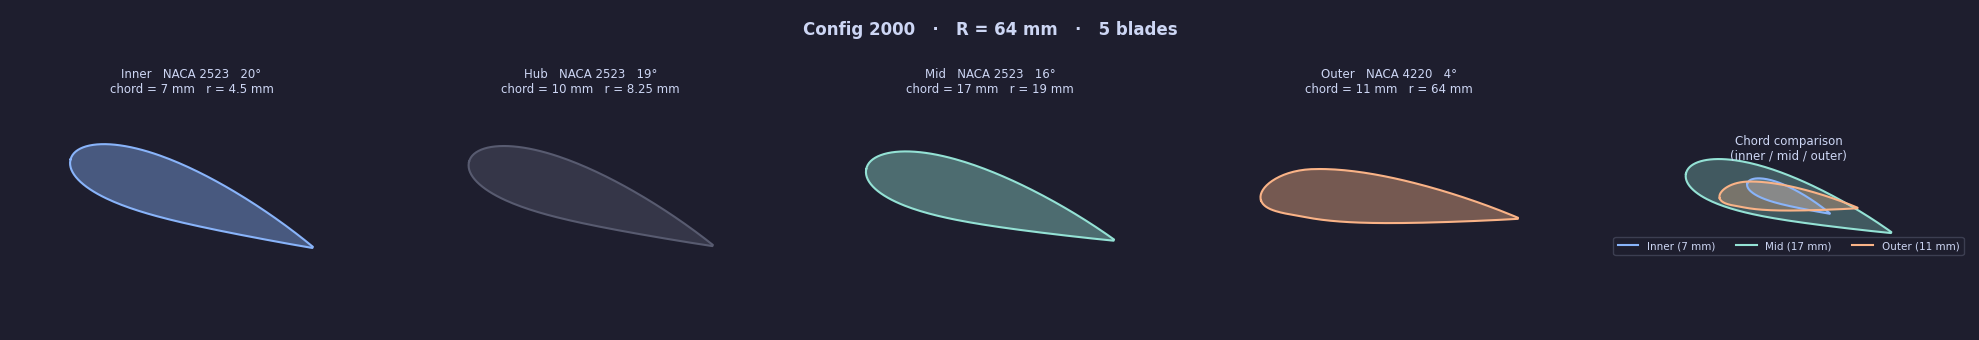

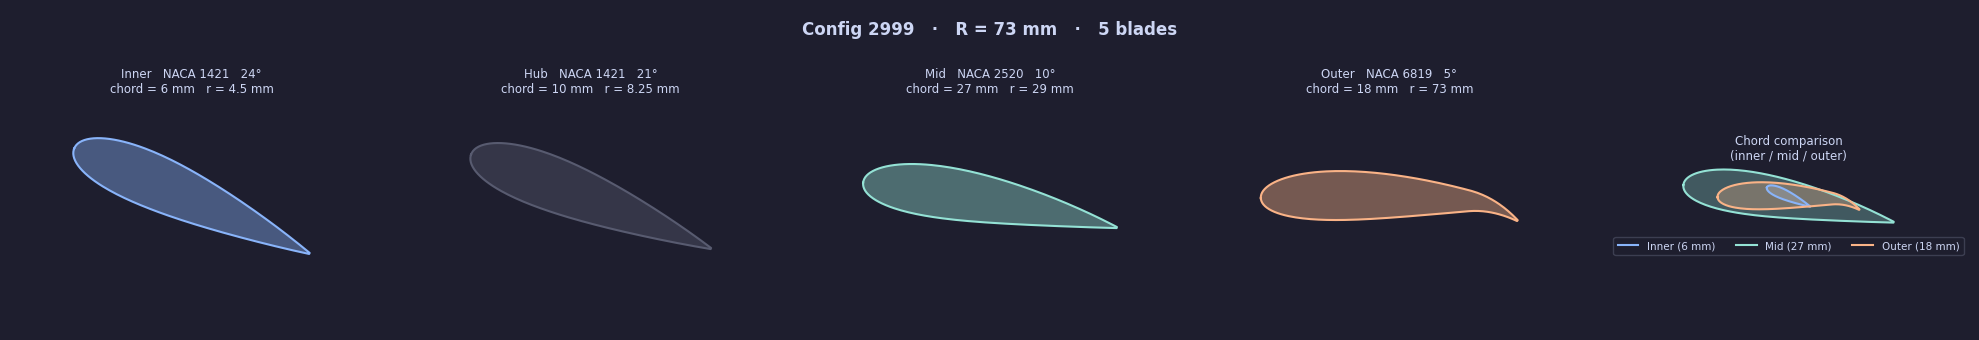

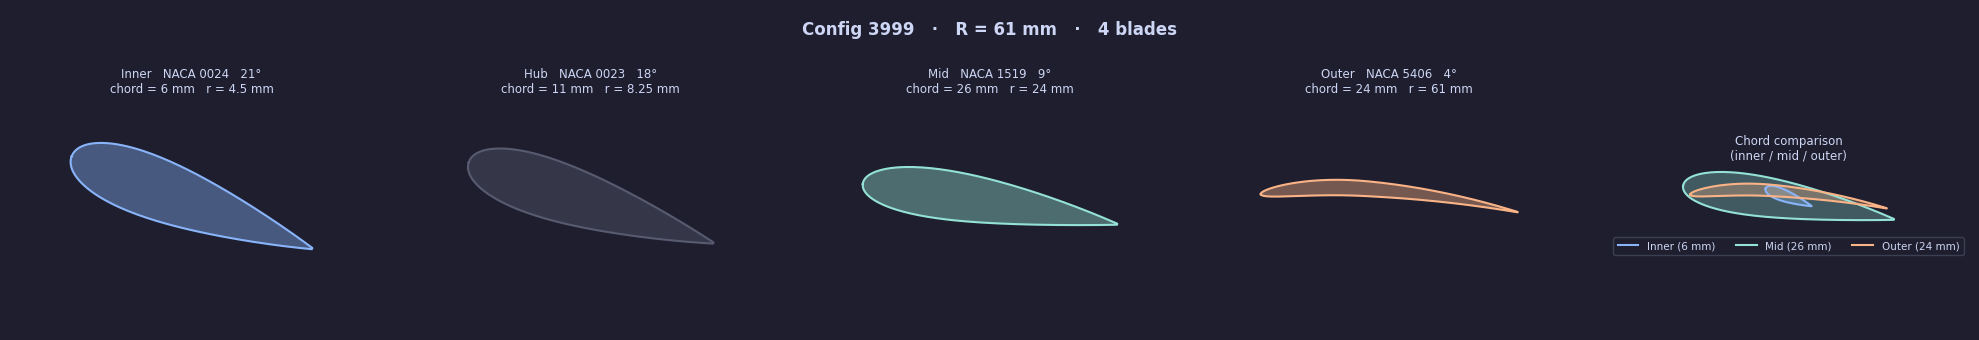

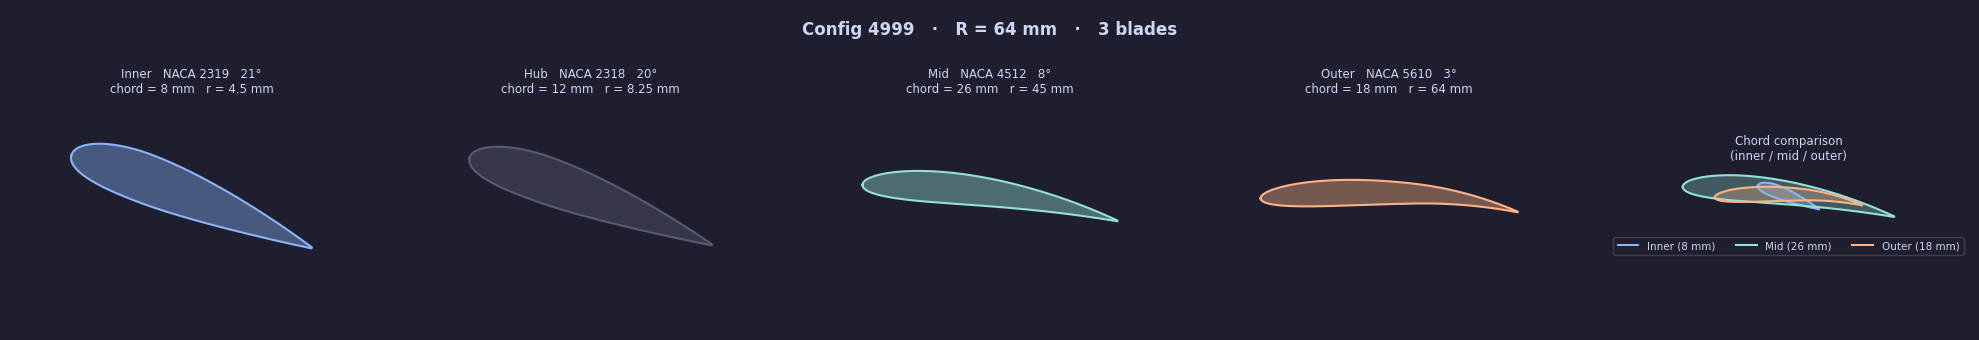

In [7]:
# -- Configuration --
N_NACA_CONFIGS  = 6
R_INNER_MM      = 4.5
R_HUB_MM        = 8.25

def naca4_coords(code, n=120):
    s = str(code).zfill(4)
    m = int(s[0])/100; p = int(s[1])/10; t = int(s[2:])/100
    x = (1 - np.cos(np.linspace(0, np.pi, n))) / 2
    yt = 5*t*(0.2969*x**0.5 - 0.1260*x - 0.3516*x**2 + 0.2843*x**3 - 0.1015*x**4)
    if m == 0 or p == 0:
        yc = np.zeros_like(x); dyc = np.zeros_like(x)
    else:
        yc  = np.where(x < p, m/p**2*(2*p*x - x**2),  m/(1-p)**2*((1-2*p)+2*p*x-x**2))
        dyc = np.where(x < p, 2*m/p**2*(p - x),        2*m/(1-p)**2*(p - x))
    theta = np.arctan(dyc)
    return (x - yt*np.sin(theta), yc + yt*np.cos(theta),
            x + yt*np.sin(theta), yc - yt*np.cos(theta))

def draw_foil_centred(ax, code, pitch_deg, chord_scale, color, alpha_fill=0.40, lw=1.5):
    xu, yu, xl, yl = naca4_coords(code)
    xu, yu, xl, yl = xu*chord_scale, yu*chord_scale, xl*chord_scale, yl*chord_scale
    ang = np.radians(-pitch_deg)
    ca, sa = np.cos(ang), np.sin(ang)
    xur = xu*ca - yu*sa; yur = xu*sa + yu*ca
    xlr = xl*ca - yl*sa; ylr = xl*sa + yl*ca
    cx = (np.concatenate([xur,xlr]).max() + np.concatenate([xur,xlr]).min()) / 2
    cy = (np.concatenate([yur,ylr]).max() + np.concatenate([yur,ylr]).min()) / 2
    fx = np.concatenate([xur, xlr[::-1]]) - cx
    fy = np.concatenate([yur, ylr[::-1]]) - cy
    ax.fill(fx, fy, color=color, alpha=alpha_fill, linewidth=0)
    ax.plot(fx, fy, color=color, linewidth=lw)

if not ok(naca_df) or not ok(geo_df):
    print('NACA or geometry CSV not available -- skipping.')
else:
    from scipy.interpolate import CubicSpline
    import matplotlib.gridspec as gridspec

    geo_cols = ['config_id', 'radius', 'mid radial pos', 'blade count',
                'inner angle', 'mid angle', 'outer angle',
                'inner chord', 'mid chord', 'outer chord']
    merged_naca = naca_df.merge(geo_df[geo_cols], on='config_id')

    def interp_at_r(row, r_target, ci, cm, co):
        r_i = R_INNER_MM; r_m = row['mid radial pos']*row['radius']; r_o = row['radius']
        xs = np.array([r_i, r_m, r_o])
        ys = np.array([row[ci], row[cm], row[co]], dtype=float)
        if r_target <= r_i + 0.01: return float(ys[0])
        return float(CubicSpline(xs, ys)(np.clip(r_target, r_i, r_o)))

    merged_naca['hub_angle'] = merged_naca.apply(
        lambda r: interp_at_r(r, R_HUB_MM, 'inner angle', 'mid angle', 'outer angle'), axis=1)
    merged_naca['hub_chord'] = merged_naca.apply(
        lambda r: interp_at_r(r, R_HUB_MM, 'inner chord', 'mid chord', 'outer chord'), axis=1)

    idx     = np.round(np.linspace(0, len(merged_naca)-1, N_NACA_CONFIGS)).astype(int)
    sampled = merged_naca.iloc[idx].reset_index(drop=True)

    station_colors = [C['blue'], C['overlay'], C['teal'], C['peach']]
    CARD_BG = '#16213E'
    PAD_EQ  = 0.52
    PAD_OV  = 0.30

    for _, prop in sampled.iterrows():
        cfg_id   = int(prop['config_id'])
        n_blades = int(prop['blade count'])
        radius   = int(prop['radius'])
        chords = {'inner': float(prop['inner chord']), 'hub': float(prop['hub_chord']),
                  'mid':   float(prop['mid chord']),   'outer': float(prop['outer chord'])}
        angles = {'inner': float(prop['inner angle']), 'hub': float(prop['hub_angle']),
                  'mid':   float(prop['mid angle']),   'outer': float(prop['outer angle'])}
        nacas  = {k: str(int(prop[f'naca_{k}'])).zfill(4)
                     if pd.notna(prop[f'naca_{k}']) else '0012'
                  for k in ['inner','hub','mid','outer']}
        max_chord = max(chords.values())
        r_labels  = {
            'inner': f'{R_INNER_MM} mm', 'hub': f'{R_HUB_MM} mm',
            'mid':   f'{prop["mid radial pos"]*radius:.0f} mm',
            'outer': f'{radius} mm'}

        fig = plt.figure(figsize=(20, 3.6), facecolor='#1E1E2E')
        gs  = gridspec.GridSpec(2, 5, figure=fig,
                                height_ratios=[0.15, 1], hspace=0.08, wspace=0.10,
                                left=0.01, right=0.99, top=0.93, bottom=0.04)

        # Title banner
        tax = fig.add_subplot(gs[0, :])
        tax.set_facecolor('#252545'); tax.axis('off')
        tax.text(0.5, 0.5, f'Config {cfg_id}   ·   R = {radius} mm   ·   {n_blades} blades',
                 transform=tax.transAxes, ha='center', va='center',
                 fontsize=12, fontweight='bold', color=C['text'])

        # Cards 0-3: equal normalised size, centred
        for col_i, (key, color) in enumerate(zip(['inner','hub','mid','outer'], station_colors)):
            ax = fig.add_subplot(gs[1, col_i])
            ax.set_facecolor(CARD_BG)
            for sp in ax.spines.values(): sp.set_edgecolor('#303060'); sp.set_linewidth(0.8)
            draw_foil_centred(ax, nacas[key], angles[key], chord_scale=1.0, color=color)
            ax.set_xlim(-PAD_EQ, PAD_EQ); ax.set_ylim(-PAD_EQ, PAD_EQ)
            ax.set_aspect('equal'); ax.axis('off')
            ax.text(0.5, 0.98,
                    f'{key.capitalize()}   NACA {nacas[key]}   {angles[key]:.0f}°\n'
                    f'chord = {chords[key]:.0f} mm   r = {r_labels[key]}',
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=8.5, color=C['text'])

        # Card 4: overlay — inner, mid, outer at real relative sizes, bounding-box centred
        ax5 = fig.add_subplot(gs[1, 4])
        ax5.set_facecolor(CARD_BG)
        for sp in ax5.spines.values(): sp.set_edgecolor('#303060'); sp.set_linewidth(0.8)

        for key, color in [('inner', station_colors[0]),
                            ('mid',   station_colors[2]),
                            ('outer', station_colors[3])]:
            chord_norm = chords[key] / max_chord
            xu, yu, xl, yl = naca4_coords(nacas[key])
            xu *= chord_norm; yu *= chord_norm; xl *= chord_norm; yl *= chord_norm
            ang = np.radians(-angles[key])
            ca, sa = np.cos(ang), np.sin(ang)
            xur = xu*ca - yu*sa; yur = xu*sa + yu*ca
            xlr = xl*ca - yl*sa; ylr = xl*sa + yl*ca
            # Centre each airfoil on its own bounding-box midpoint
            cx = (np.concatenate([xur,xlr]).max() + np.concatenate([xur,xlr]).min()) / 2
            cy = (np.concatenate([yur,ylr]).max() + np.concatenate([yur,ylr]).min()) / 2
            fx = np.concatenate([xur, xlr[::-1]]) - cx
            fy = np.concatenate([yur, ylr[::-1]]) - cy
            ax5.fill(fx, fy, color=color, alpha=0.30, linewidth=0)
            ax5.plot(fx, fy, color=color, linewidth=1.5,
                     label=f'{key.capitalize()} ({chords[key]:.0f} mm)')

        ax5.set_xlim(-PAD_OV - 0.55, PAD_OV + 0.55)
        ax5.set_ylim(-PAD_OV, PAD_OV)
        ax5.set_aspect('equal'); ax5.axis('off')
        ax5.text(0.5, 0.98, 'Chord comparison\n(inner / mid / outer)',
                 transform=ax5.transAxes, ha='center', va='top',
                 fontsize=8.5, color=C['text'])
        ax5.legend(loc='lower center', fontsize=7.5, ncol=3,
                   facecolor='#1E1E2E', edgecolor='#44475A',
                   labelcolor=C['text'], framealpha=0.8)

        plt.savefig(f'plots/naca_cfg{cfg_id}.png', dpi=130,
                    bbox_inches='tight', facecolor='#1E1E2E')
        plt.show()


## 7. Notebook 4 — XFOIL aerodynamic coefficients

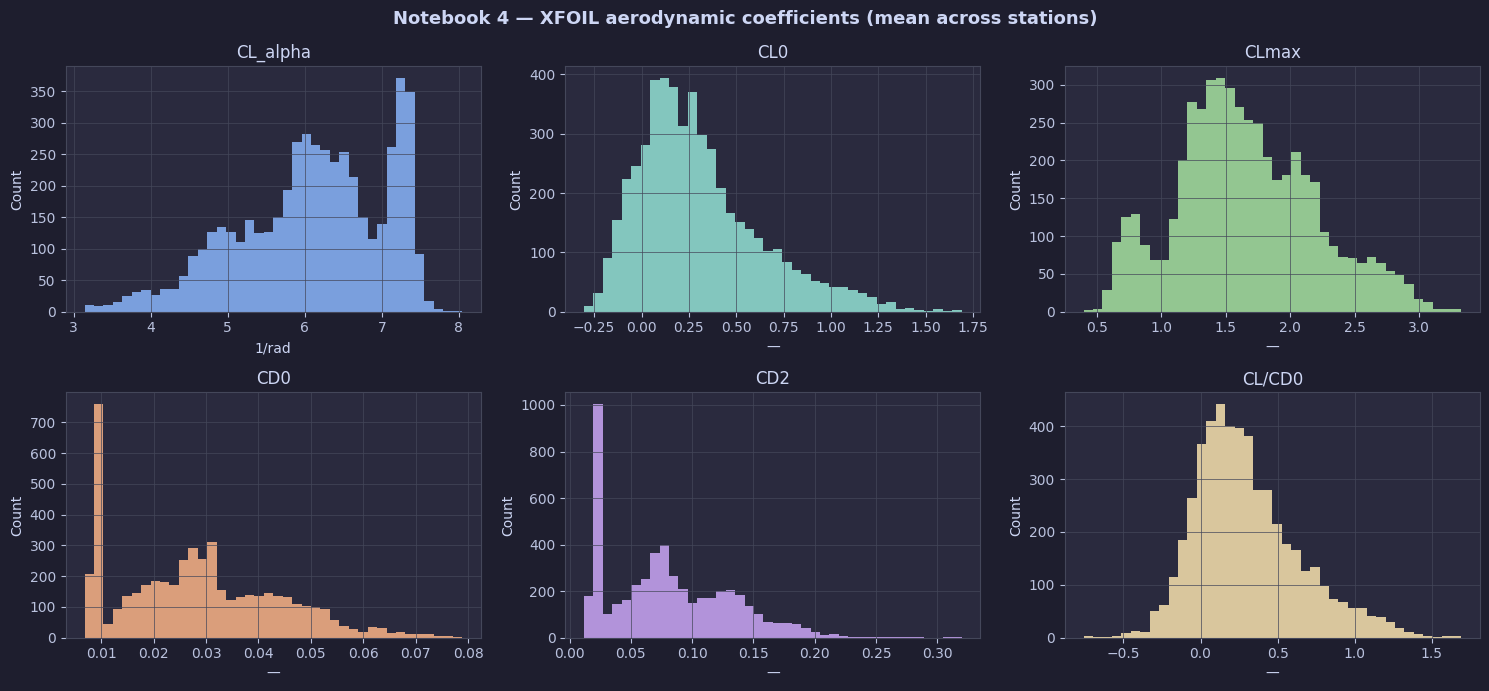

In [8]:
if not ok(xfoil_df):
    print('XFOIL CSV not available — skipping.')
else:
    # Aggregate across stations: take mean of hub/mid/outer for each coefficient
    agg = pd.DataFrame({'config_id': xfoil_df['config_id']})
    coeff_map = {
        'CL_alpha':  ['hub_CL_a',  'mid_CL_a',  'outer_CL_a'],
        'CL0':       ['hub_CL0',   'mid_CL0',   'outer_CL0'],
        'CLmax':     ['hub_CLmax', 'mid_CLmax', 'outer_CLmax'],
        'CD0':       ['hub_CD0',   'mid_CD0',   'outer_CD0'],
        'CD2':       ['hub_CD2u',  'mid_CD2u',  'outer_CD2u'],
        'CL/CD0':    ['hub_CLCD0', 'mid_CLCD0', 'outer_CLCD0'],
    }
    for label, cols in coeff_map.items():
        valid = [c for c in cols if c in xfoil_df.columns]
        if valid:
            agg[label] = xfoil_df[valid].mean(axis=1)

    plot_cols = [c for c in coeff_map.keys() if c in agg.columns]
    units = {
        'CL_alpha': '1/rad', 'CL0': '—', 'CLmax': '—',
        'CD0': '—', 'CD2': '—', 'CL/CD0': '—'
    }
    colors_list = [C['blue'], C['teal'], C['green'], C['peach'], C['mauve'], C['yellow']]

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    fig.suptitle('Notebook 4 — XFOIL aerodynamic coefficients (mean across stations)')

    for ax, col, color in zip(axes.ravel(), plot_cols, colors_list):
        ax.hist(agg[col].dropna(), bins=40, color=color, edgecolor='none', alpha=0.85)
        ax.set_xlabel(units.get(col, '—'))
        ax.set_ylabel('Count')
        ax.set_title(col)

    for ax in axes.ravel()[len(plot_cols):]:
        ax.axis('off')

    fig.tight_layout()
    plt.show()

## 8. Notebook 6 — QPROP performance

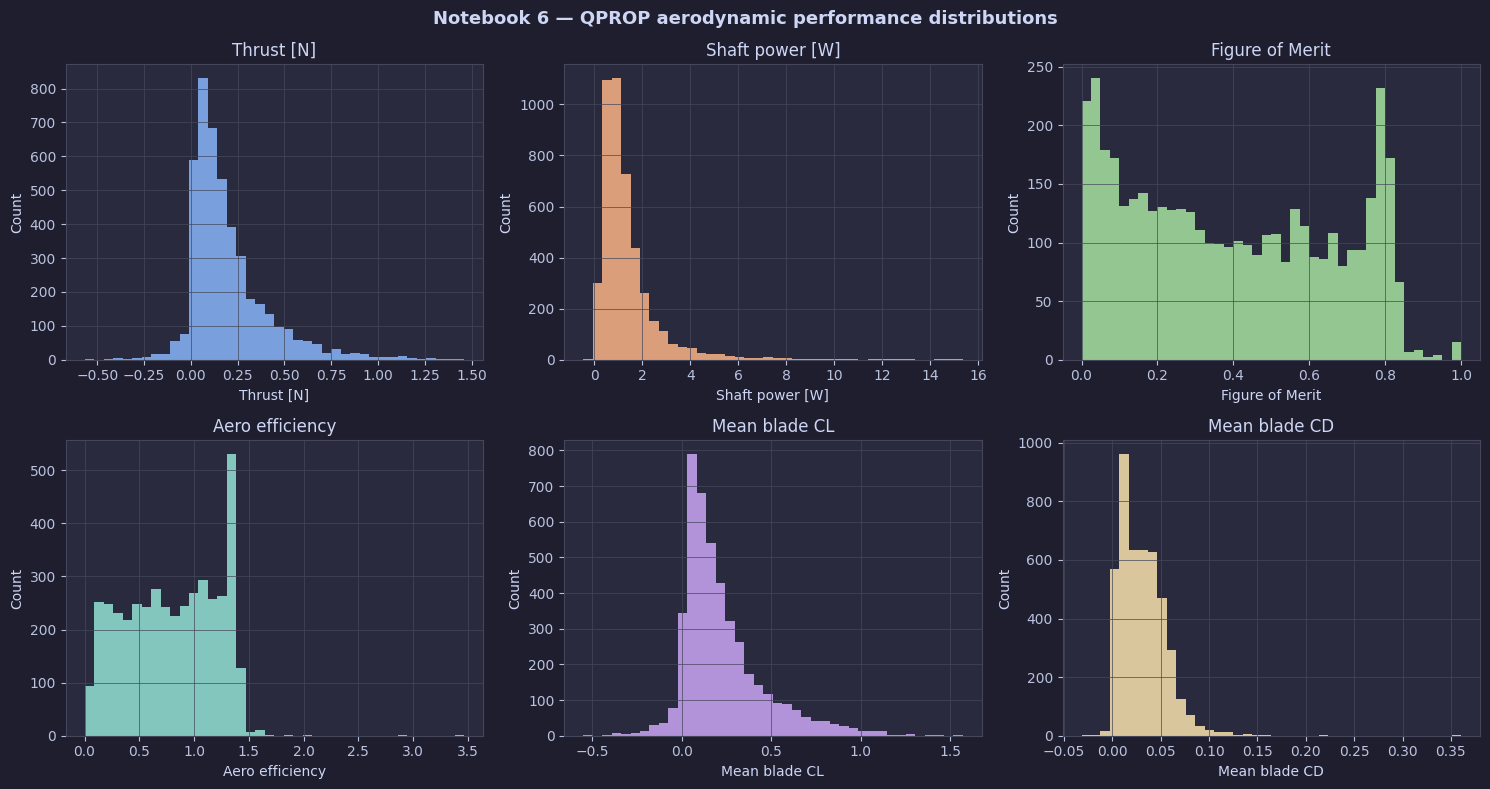

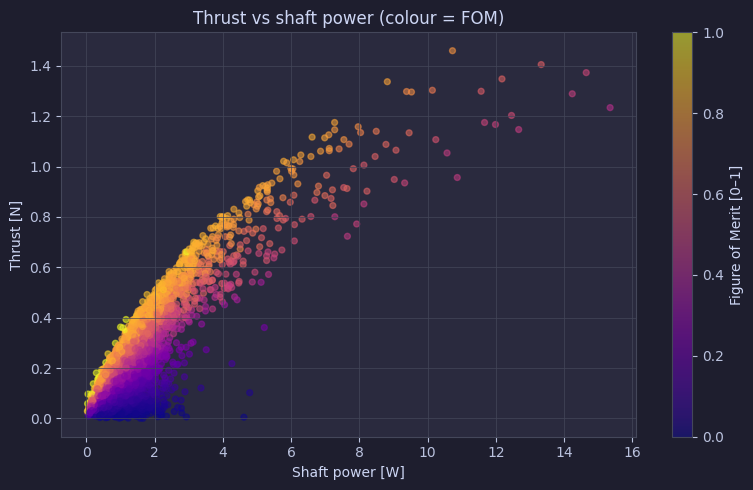

In [9]:
if not ok(qprop_df):
    print('QPROP CSV not available — skipping.')
else:
    q = qprop_df[qprop_df['qprop_ok'] == True].copy()
    # Clip FOM to [0, 1]
    if 'FOM' in q.columns:
        q['FOM'] = q['FOM'].clip(0, 1)

    # Distributions
    hist_specs = [
        ('T',        'Thrust [N]',        C['blue']),
        ('Pshaft',   'Shaft power [W]',   C['peach']),
        ('FOM',      'Figure of Merit',   C['green']),
        ('eff_aero', 'Aero efficiency',   C['teal']),
        ('cl_avg',   'Mean blade CL',     C['mauve']),
        ('cd_avg',   'Mean blade CD',     C['yellow']),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Notebook 6 — QPROP aerodynamic performance distributions')
    for ax, (col, label, color) in zip(axes.ravel(), hist_specs):
        if col not in q.columns: ax.axis('off'); continue
        ax.hist(q[col].dropna(), bins=40, color=color, edgecolor='none', alpha=0.85)
        ax.set_xlabel(label); ax.set_ylabel('Count'); ax.set_title(label)
    fig.tight_layout(); plt.show()

    # Scatter: thrust vs power coloured by FOM
    if {'T', 'Pshaft', 'FOM'}.issubset(q.columns):
        fig, ax = plt.subplots(figsize=(8, 5))
        sc = ax.scatter(q['Pshaft'], q['T'], c=q['FOM'], cmap='plasma',
                        vmin=0, vmax=1, alpha=0.55, s=18)
        fig.colorbar(sc, ax=ax, label='Figure of Merit [0–1]')
        ax.set_xlabel('Shaft power [W]'); ax.set_ylabel('Thrust [N]')
        ax.set_title('Thrust vs shaft power (colour = FOM)')
        fig.tight_layout(); plt.show()

## 9. Notebook 7 — Flight dynamics

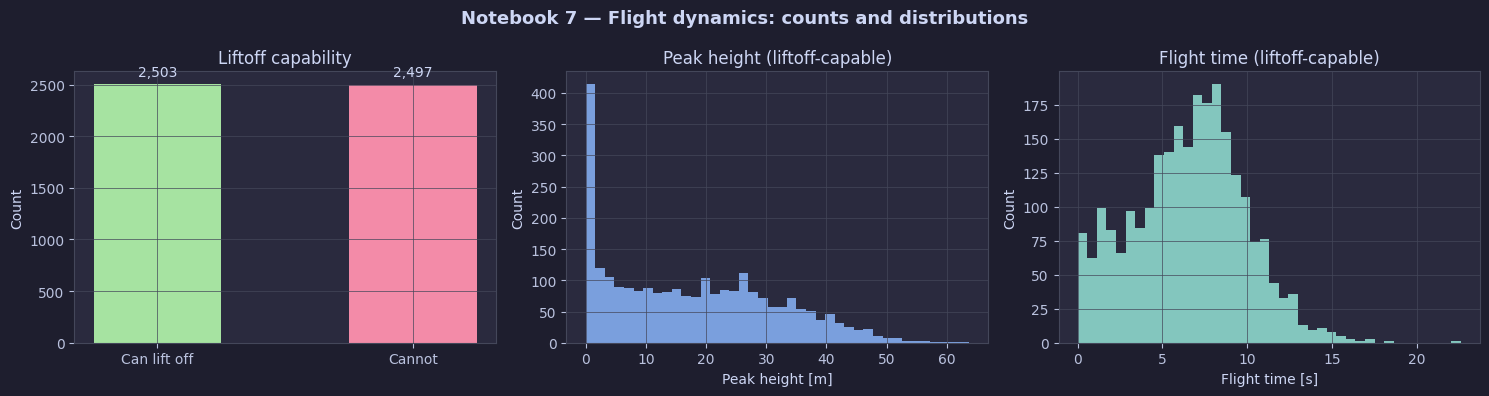

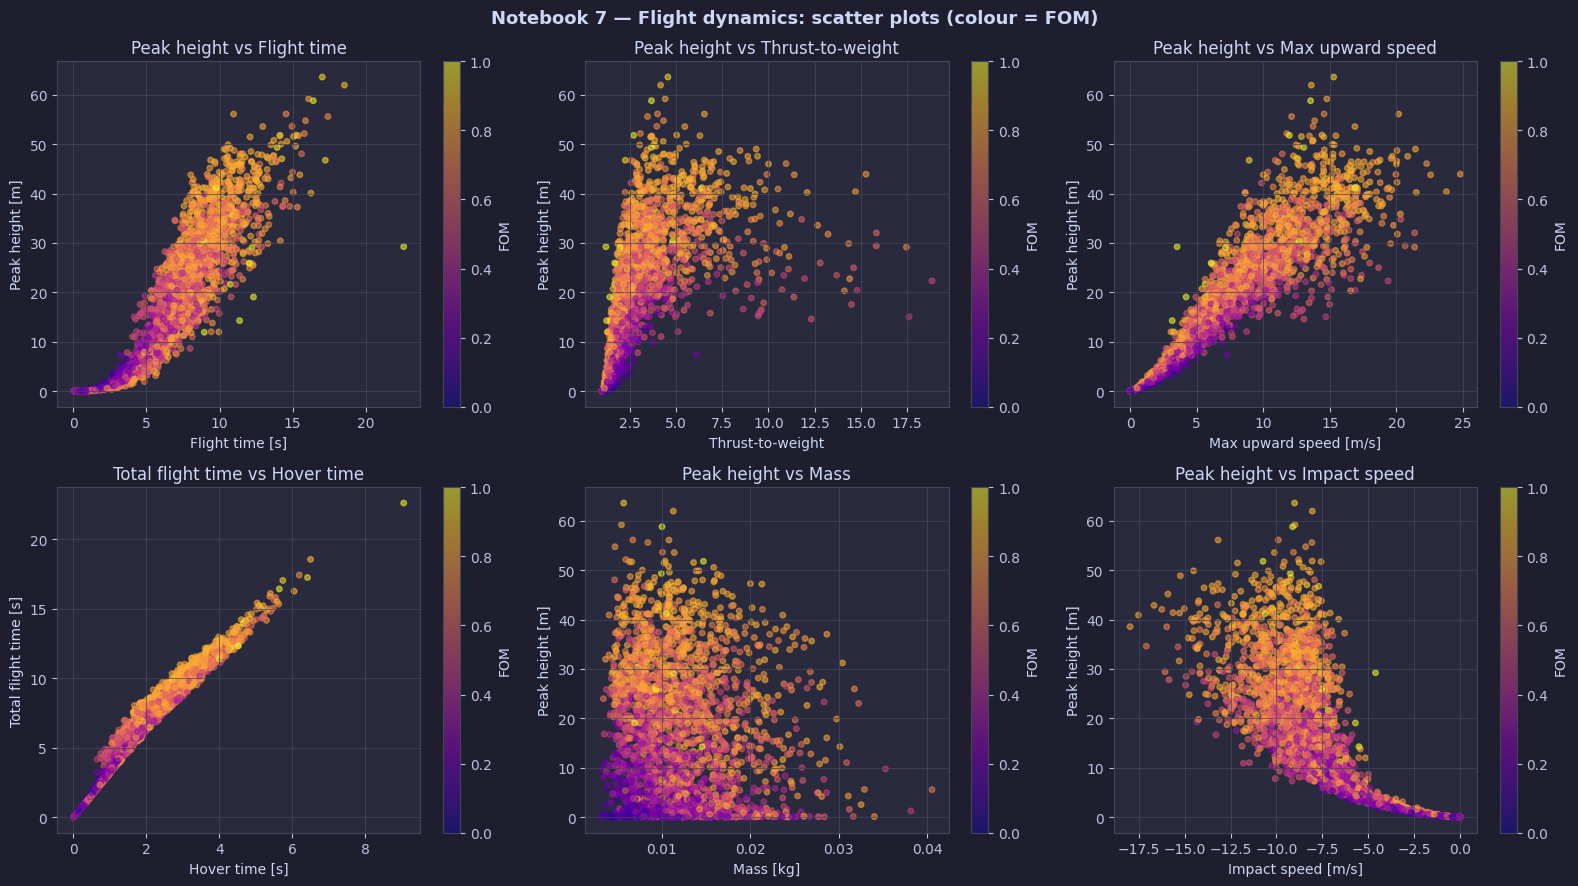

In [10]:
if not ok(flight_df):
    print('Flight dynamics CSV not available — skipping.')
else:
    fly = flight_df.copy()
    liftoff = fly[fly.get('can_liftoff', pd.Series([True]*len(fly))) == True] \
              if 'can_liftoff' in fly.columns else fly

    # Get FOM for colouring
    fom_col = None
    if ok(qprop_df) and 'FOM' in qprop_df.columns:
        fom_map = qprop_df[['config_id', 'FOM']].copy()
        fom_map['FOM'] = fom_map['FOM'].clip(0, 1)
        liftoff = liftoff.merge(fom_map, on='config_id', how='left')
        fom_col = 'FOM'

    # ── Row 1: count plots ──
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Notebook 7 — Flight dynamics: counts and distributions')

    # Liftoff count
    if 'can_liftoff' in fly.columns:
        counts = fly['can_liftoff'].value_counts()
        vals = [counts.get(True, 0), counts.get(False, 0)]
        b = axes[0].bar(['Can lift off', 'Cannot'], vals,
                        color=[C['green'], C['red']], width=0.5)
        axes[0].bar_label(b, labels=[f'{v:,}' for v in vals], padding=4, fontsize=10)
        axes[0].set_ylabel('Count'); axes[0].set_title('Liftoff capability')

    # Peak height histogram
    if 'h_max_m' in liftoff.columns:
        axes[1].hist(liftoff['h_max_m'].dropna(), bins=40,
                     color=C['blue'], edgecolor='none', alpha=0.85)
        axes[1].set_xlabel('Peak height [m]'); axes[1].set_ylabel('Count')
        axes[1].set_title('Peak height (liftoff-capable)')

    # Flight time histogram
    if 'flight_time_s' in liftoff.columns:
        axes[2].hist(liftoff['flight_time_s'].dropna(), bins=40,
                     color=C['teal'], edgecolor='none', alpha=0.85)
        axes[2].set_xlabel('Flight time [s]'); axes[2].set_ylabel('Count')
        axes[2].set_title('Flight time (liftoff-capable)')

    fig.tight_layout(); plt.show()

    # ── Row 2: vs plots coloured by FOM ──
    vs_pairs = [
        ('flight_time_s', 'h_max_m',        'Flight time [s]',      'Peak height [m]'),
        ('T_over_W_static','h_max_m',        'Thrust-to-weight',     'Peak height [m]'),
        ('v_max_up_m_s',  'h_max_m',         'Max upward speed [m/s]','Peak height [m]'),
        ('hover_time_s',  'flight_time_s',   'Hover time [s]',       'Total flight time [s]'),
        ('mass_kg',       'h_max_m',          'Mass [kg]',            'Peak height [m]'),
        ('v_impact_m_s',  'h_max_m',          'Impact speed [m/s]',   'Peak height [m]'),
    ]
    valid_pairs = [(x, y, xl, yl) for x, y, xl, yl in vs_pairs
                   if x in liftoff.columns and y in liftoff.columns]

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('Notebook 7 — Flight dynamics: scatter plots (colour = FOM)')

    for ax, (xcol, ycol, xlabel, ylabel) in zip(axes.ravel(), valid_pairs):
        sub = liftoff[[xcol, ycol] + ([fom_col] if fom_col else [])].dropna()
        if fom_col and fom_col in sub.columns:
            sc = ax.scatter(sub[xcol], sub[ycol], c=sub[fom_col], cmap='plasma',
                            vmin=0, vmax=1, alpha=0.55, s=16)
            fig.colorbar(sc, ax=ax, label='FOM')
        else:
            ax.scatter(sub[xcol], sub[ycol], color=C['blue'], alpha=0.45, s=16)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel.split(" [")[0]} vs {xlabel.split(" [")[0]}')

    for ax in axes.ravel()[len(valid_pairs):]:
        ax.axis('off')

    fig.tight_layout(); plt.show()

## 10. Notebook 8 — Representative propellers

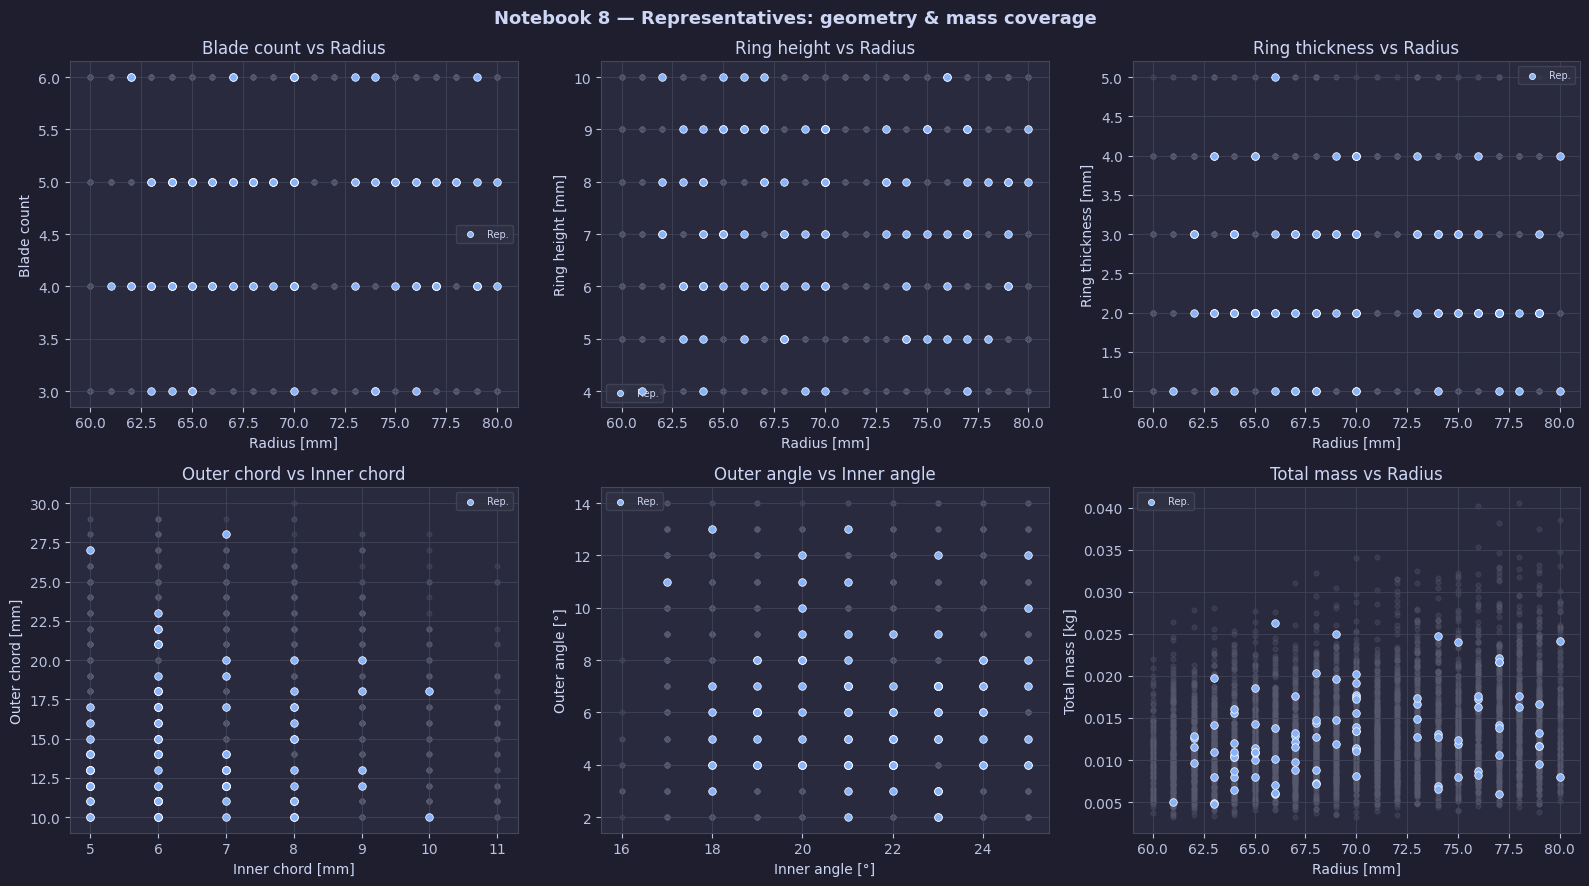

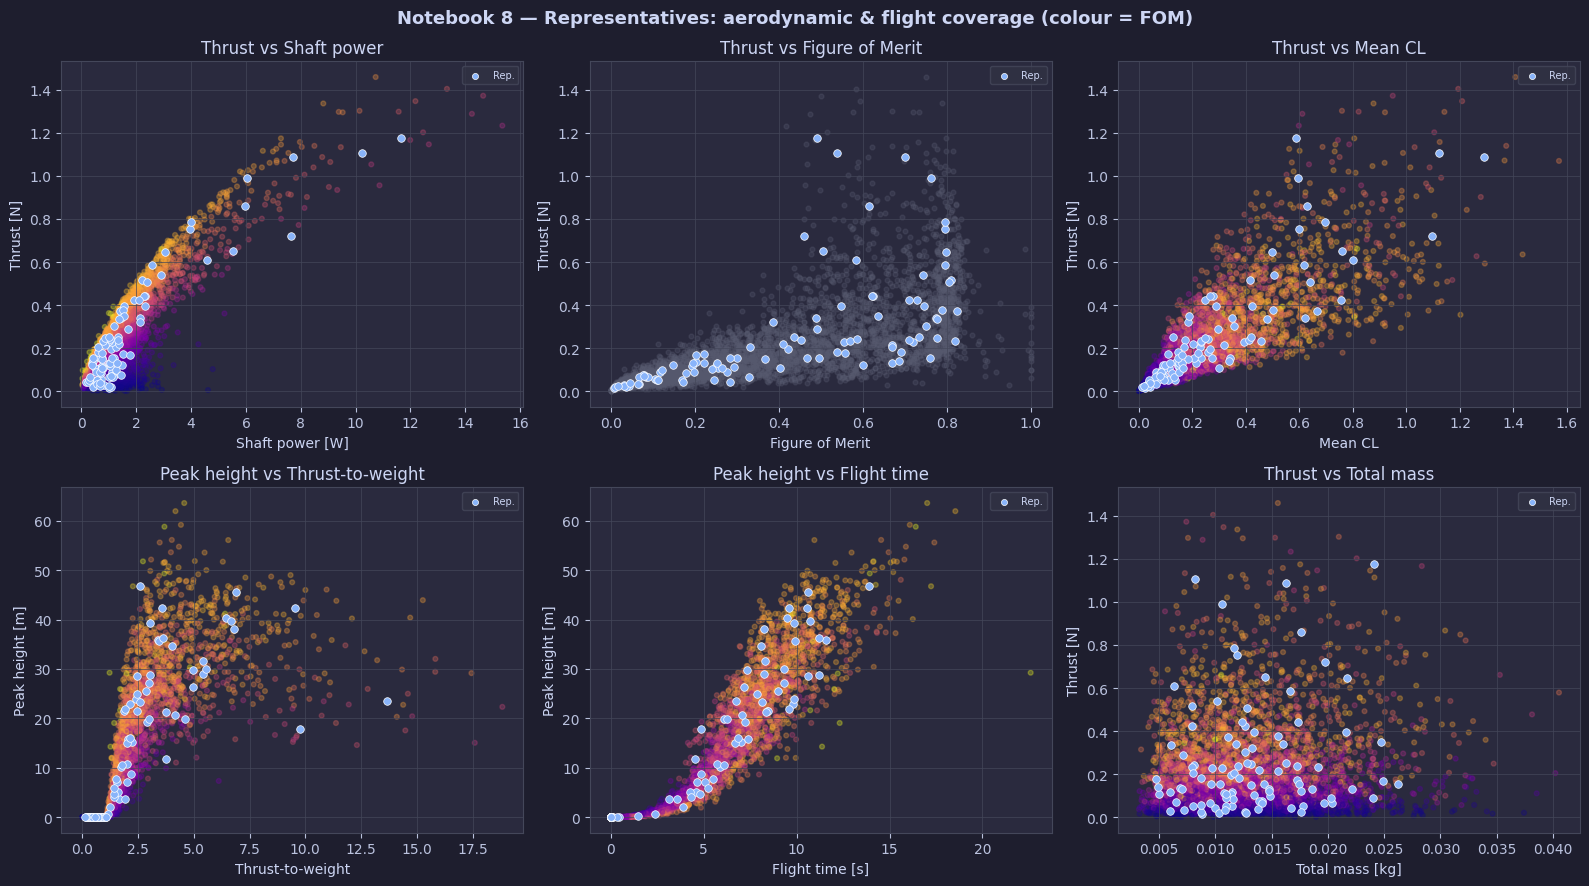

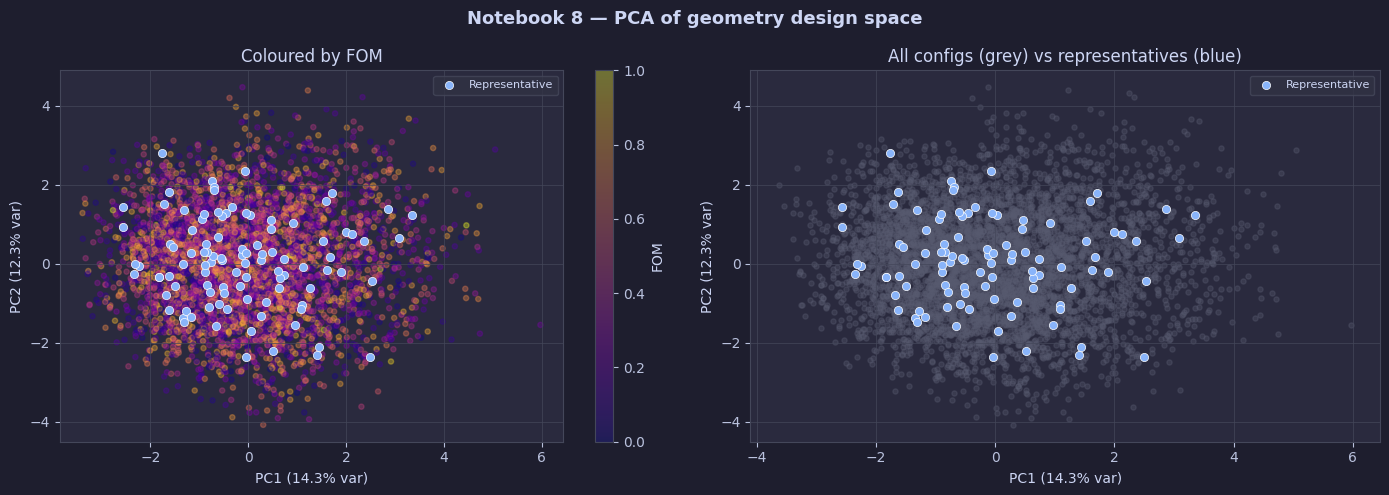

In [11]:
if not ok(rep_df):
    print('Representative propellers CSV not available — skipping.')
else:
    rep_ids = set(rep_df['config_id'].values)

    # Merge all available data
    full = geo_df.copy() if ok(geo_df) else None
    for df in [mass_df, qprop_df, flight_df]:
        if ok(df) and full is not None:
            full = full.merge(df, on='config_id', suffixes=('', '_dup'))
            full = full.loc[:, ~full.columns.str.endswith('_dup')]

    if full is None:
        print('Need geometry CSV for representative plots.')
    else:
        if 'FOM' in full.columns:
            full['FOM'] = full['FOM'].clip(0, 1)
        mask = full['config_id'].isin(rep_ids)
        all_pts = full[~mask]
        rep_pts = full[mask]

        def scatter_rep(ax, xcol, ycol, xlabel, ylabel, cmap_col=None):
            if xcol not in full.columns or ycol not in full.columns:
                ax.axis('off'); return
            if cmap_col and cmap_col in full.columns:
                sc = ax.scatter(all_pts[xcol], all_pts[ycol],
                                c=all_pts[cmap_col], cmap='plasma',
                                vmin=0, vmax=1, alpha=0.3, s=12)
            else:
                ax.scatter(all_pts[xcol], all_pts[ycol],
                           color=C['overlay'], alpha=0.3, s=12)
            ax.scatter(rep_pts[xcol], rep_pts[ycol],
                       color=C['blue'], s=30, zorder=6,
                       edgecolors='white', linewidths=0.5, label='Rep.')
            ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
            ax.set_title(f'{ylabel.split(" [")[0]} vs {xlabel.split(" [")[0]}')

        # ── Grid 1: geometry and mass ──
        fig, axes = plt.subplots(2, 3, figsize=(16, 9))
        fig.suptitle('Notebook 8 — Representatives: geometry & mass coverage')
        scatter_rep(axes[0,0], 'radius', 'blade count',   'Radius [mm]',     'Blade count')
        scatter_rep(axes[0,1], 'radius', 'ring height',   'Radius [mm]',     'Ring height [mm]')
        scatter_rep(axes[0,2], 'radius', 'ring thickness','Radius [mm]',     'Ring thickness [mm]')
        scatter_rep(axes[1,0], 'inner chord', 'outer chord','Inner chord [mm]','Outer chord [mm]')
        scatter_rep(axes[1,1], 'inner angle', 'outer angle','Inner angle [°]', 'Outer angle [°]')
        scatter_rep(axes[1,2], 'radius', 'm_total_kg',    'Radius [mm]',     'Total mass [kg]')
        for ax in axes.ravel():
            if ax.has_data(): ax.legend(fontsize=7, markerscale=0.8)
        fig.tight_layout(); plt.show()

        # ── Grid 2: performance ──
        fig, axes = plt.subplots(2, 3, figsize=(16, 9))
        fig.suptitle('Notebook 8 — Representatives: aerodynamic & flight coverage (colour = FOM)')
        fom_c = 'FOM' if 'FOM' in full.columns else None
        scatter_rep(axes[0,0], 'Pshaft',       'T',         'Shaft power [W]',   'Thrust [N]',         fom_c)
        scatter_rep(axes[0,1], 'FOM',           'T',         'Figure of Merit',   'Thrust [N]',         None)
        scatter_rep(axes[0,2], 'cl_avg',        'T',         'Mean CL',           'Thrust [N]',         fom_c)
        scatter_rep(axes[1,0], 'T_over_W_static','h_max_m',  'Thrust-to-weight',  'Peak height [m]',    fom_c)
        scatter_rep(axes[1,1], 'flight_time_s', 'h_max_m',  'Flight time [s]',   'Peak height [m]',    fom_c)
        scatter_rep(axes[1,2], 'm_total_kg',    'T',         'Total mass [kg]',   'Thrust [N]',         fom_c)
        for ax in axes.ravel():
            if ax.has_data(): ax.legend(fontsize=7, markerscale=0.8)
        fig.tight_layout(); plt.show()

        # ── PCA plot ──
        pca_cols = [c for c in [
            'radius', 'blade count', 'ring height', 'ring thickness',
            'inner chord', 'mid chord', 'outer chord',
            'inner angle', 'mid angle', 'outer angle',
            'inner thickness', 'outer thickness',
            'inner camber', 'outer camber', 'mid radial pos',
        ] if c in full.columns]

        pca_data = full[pca_cols].dropna()
        if len(pca_data) > 10 and len(pca_cols) >= 2:
            scaler = StandardScaler()
            X = scaler.fit_transform(pca_data)
            pca = PCA(n_components=2)
            comps = pca.fit_transform(X)
            pca_df = pd.DataFrame(comps, columns=['PC1', 'PC2'],
                                  index=pca_data.index)
            pca_df['config_id'] = full.loc[pca_data.index, 'config_id'].values
            pca_df['is_rep']    = pca_df['config_id'].isin(rep_ids)
            if fom_c and fom_c in full.columns:
                pca_df['FOM'] = full.loc[pca_data.index, fom_c].values

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle('Notebook 8 — PCA of geometry design space')
            var = pca.explained_variance_ratio_

            for ax, (c_col, c_label, cmap) in zip(axes, [
                ('FOM' if 'FOM' in pca_df.columns else None, 'FOM', 'plasma'),
                (None, '', None),
            ]):
                non_rep = pca_df[~pca_df['is_rep']]
                rep_p   = pca_df[pca_df['is_rep']]

                if c_col and c_col in pca_df.columns:
                    sc = ax.scatter(non_rep['PC1'], non_rep['PC2'],
                                    c=non_rep[c_col], cmap=cmap,
                                    vmin=0, vmax=1, alpha=0.35, s=14)
                    fig.colorbar(sc, ax=ax, label=c_label)
                else:
                    ax.scatter(non_rep['PC1'], non_rep['PC2'],
                               color=C['overlay'], alpha=0.35, s=14)

                ax.scatter(rep_p['PC1'], rep_p['PC2'],
                           color=C['blue'], s=35, zorder=6,
                           edgecolors='white', linewidths=0.5, label='Representative')
                ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% var)')
                ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% var)')
                ax.set_title('Coloured by FOM' if c_col else 'All configs (grey) vs representatives (blue)')
                ax.legend(fontsize=8)

            fig.tight_layout(); plt.show()

## 11. Notebook 9 — STL geometry volumes

ValueError: arange: cannot compute length

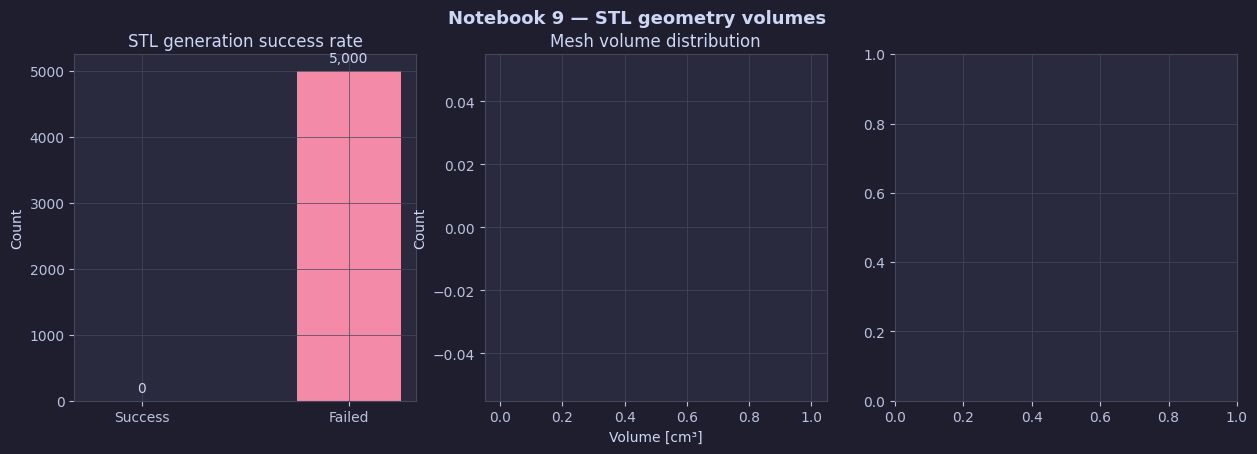

In [12]:
if not ok(stl_df):
    print('STL generation CSV not available — skipping.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle('Notebook 9 — STL geometry volumes')

    counts = stl_df['geometry_ok'].value_counts()
    vals = [counts.get(True, 0), counts.get(False, 0)]
    b = axes[0].bar(['Success', 'Failed'], vals,
                    color=[C['green'], C['red']], width=0.5)
    axes[0].bar_label(b, labels=[f'{v:,}' for v in vals], padding=4, fontsize=10)
    axes[0].set_ylabel('Count'); axes[0].set_title('STL generation success rate')

    ok_stl = stl_df[stl_df['geometry_ok'] == True]

    if 'volume_mm3' in ok_stl.columns:
        axes[1].hist(ok_stl['volume_mm3'].dropna() / 1e3, bins=40,
                     color=C['teal'], edgecolor='none', alpha=0.85)
        axes[1].set_xlabel('Volume [cm³]'); axes[1].set_ylabel('Count')
        axes[1].set_title('Mesh volume distribution')

    if ok(geo_df) and 'volume_mm3' in ok_stl.columns:
        merged = geo_df[['config_id', 'radius']].merge(
            ok_stl[['config_id', 'volume_mm3']], on='config_id')
        bins   = np.arange(merged['radius'].min() - 1,
                           merged['radius'].max() + 2, 2)
        merged['r_bin'] = pd.cut(merged['radius'], bins=bins)
        groups = [g['volume_mm3'].dropna().values / 1e3
                  for _, g in merged.groupby('r_bin', observed=True)]
        bin_labels = [f'{int(b.left)}' for b in
                      merged.groupby('r_bin', observed=True).groups.keys()]
        styled_box(axes[2], groups, bin_labels, [C['teal']] * len(groups))
        axes[2].set_xlabel('Radius bin [mm]'); axes[2].set_ylabel('Volume [cm³]')
        axes[2].set_title('Volume vs radius (binned)')
        axes[2].tick_params(axis='x', rotation=45)
    else:
        axes[2].axis('off')

    fig.tight_layout(); plt.show()